In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/raw/Gaming and Mental Health.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1000, 27)

Columns:
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   str    
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   str    
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   str    
 5   primary_game                      1000 non-null   str    
 6   gaming_platform                   1000 non-null   str    
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   str    
 9   sleep_disruption_frequency        1000 non-null   str    
 10  academic_work_performance         1000 non-null   str    
 11  grades_gpa                        754 non-null    float64
 12  work_productivity_

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1000,1000,GD0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.475,4.116105,13.0,18.0,20.0,22.0,35.0
gender,1000,3,Male,647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_gaming_hours,1000.0,NaN,NaN,NaN,6.1514,2.867194,0.5,4.1,6.0,8.025,15.1
game_genre,1000,7,MOBA,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_game,1000,24,Dota 2,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gaming_platform,1000,4,Mobile,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,1000.0,NaN,NaN,NaN,5.7381,1.441213,3.0,4.8,5.7,6.6,9.0
sleep_quality,1000,5,Fair,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_disruption_frequency,1000,5,Often,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df.head()

C:\Users\Boris\AppData\Local\Temp\ipykernel_4132\103085383.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [8]:
target_col = "gaming_addiction_risk_level"

print("Unique target values:")
print(df[target_col].unique())

Unique target values:
<StringArray>
['Severe', 'Low', 'High', 'Moderate']
Length: 4, dtype: str


In [9]:
target_counts = df[target_col].value_counts().sort_index()
target_counts

gaming_addiction_risk_level
High        154
Low         514
Moderate    190
Severe      142
Name: count, dtype: int64

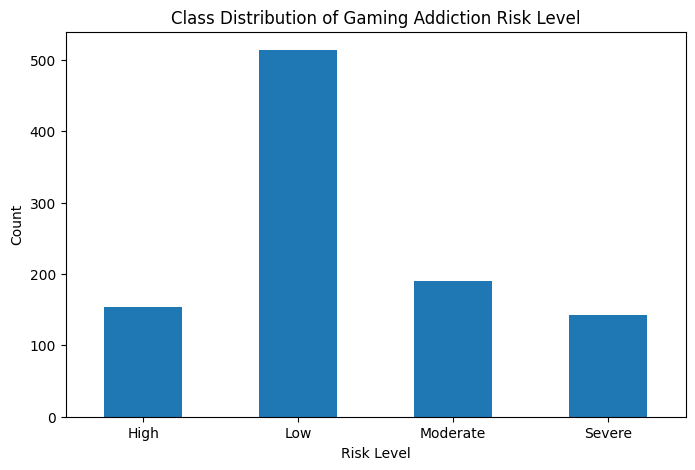

In [10]:
target_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution of Gaming Addiction Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values per column:")
missing

Missing values per column:


work_productivity_score    326
grades_gpa                 246
dtype: int64

In [12]:
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]

print("Missing percentage per column:")
missing_ratio

Missing percentage per column:


work_productivity_score    32.6
grades_gpa                 24.6
dtype: float64